In [2]:
# 1. importing the datasets


import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.datasets import fetch_california_housing
dataset = fetch_california_housing()
print(dataset.data)


[[   8.3252       41.            6.98412698 ...    2.55555556
    37.88       -122.23      ]
 [   8.3014       21.            6.23813708 ...    2.10984183
    37.86       -122.22      ]
 [   7.2574       52.            8.28813559 ...    2.80225989
    37.85       -122.24      ]
 ...
 [   1.7          17.            5.20554273 ...    2.3256351
    39.43       -121.22      ]
 [   1.8672       18.            5.32951289 ...    2.12320917
    39.43       -121.32      ]
 [   2.3886       16.            5.25471698 ...    2.61698113
    39.37       -121.24      ]]


In [3]:
# changing it to pandas dataframe

df = pd.DataFrame(dataset.data, columns = dataset.feature_names)
print(df.shape)   # 20,640 rows and 8 columns 
print(dataset.feature_names)

(20640, 8)
['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']


In [4]:
# 2. Data cleaning

In [5]:
print(df.describe())

             MedInc      HouseAge      AveRooms     AveBedrms    Population  \
count  20640.000000  20640.000000  20640.000000  20640.000000  20640.000000   
mean       3.870671     28.639486      5.429000      1.096675   1425.476744   
std        1.899822     12.585558      2.474173      0.473911   1132.462122   
min        0.499900      1.000000      0.846154      0.333333      3.000000   
25%        2.563400     18.000000      4.440716      1.006079    787.000000   
50%        3.534800     29.000000      5.229129      1.048780   1166.000000   
75%        4.743250     37.000000      6.052381      1.099526   1725.000000   
max       15.000100     52.000000    141.909091     34.066667  35682.000000   

           AveOccup      Latitude     Longitude  
count  20640.000000  20640.000000  20640.000000  
mean       3.070655     35.631861   -119.569704  
std       10.386050      2.135952      2.003532  
min        0.692308     32.540000   -124.350000  
25%        2.429741     33.930000   -1

In [6]:
df.head(5)

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


In [7]:
#checking missing values
print(df.isna().sum()) 

# checking duplicate values
print("Duplicated count :{}".format(df.duplicated().sum())) 
# 0 duplicate and no missing values

MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
dtype: int64
Duplicated count :0


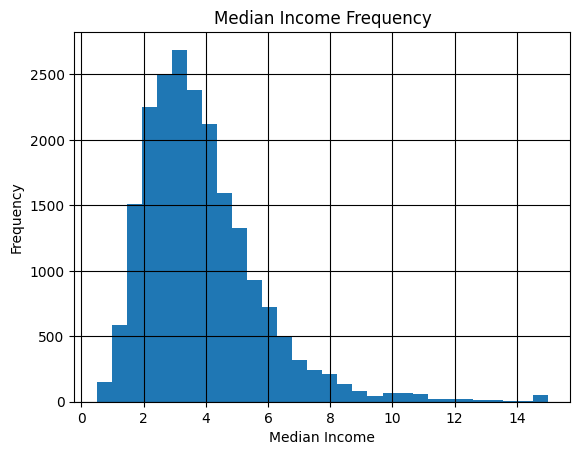

the data skewness : 2


In [8]:
# 3. Exploratory Data Analysis (EDA)

plt.hist(df['MedInc'], bins=30)
plt.xlabel("Median Income")
plt.ylabel("Frequency")
plt.title("Median Income Frequency")
plt.grid(color = "black")
plt.show() 
print("the data skewness : {}".format(round(df["MedInc"].skew()),2))
         

the skewness is : 0.06033063759913685


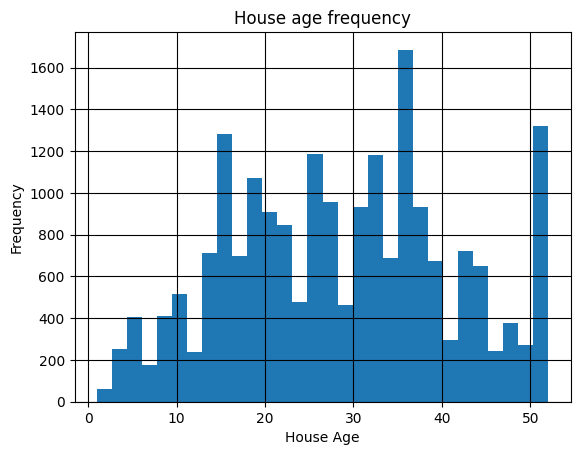

In [9]:
print("the skewness is : {}".format(df['HouseAge'].skew()))
plt.hist(df['HouseAge'], bins=30)
plt.xlabel("House Age")
plt.ylabel("Frequency")
plt.title("House age frequency")
plt.grid(color = "black")
plt.show()        
         

the average room skewness id : 20.69786895671065


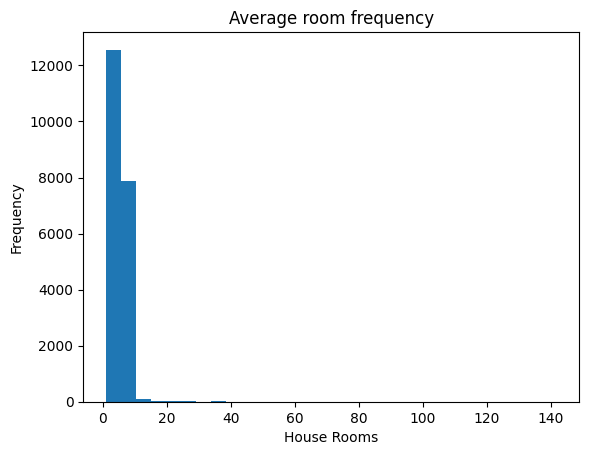

In [10]:
print("the average room skewness id : {}".format(df['AveRooms'].skew()))

plt.hist(df['AveRooms'], bins=30)
plt.xlabel("House Rooms")
plt.ylabel("Frequency")
plt.title("Average room frequency")
plt.show()       

the skewness of Average Bedrooms: 31.316956246782674


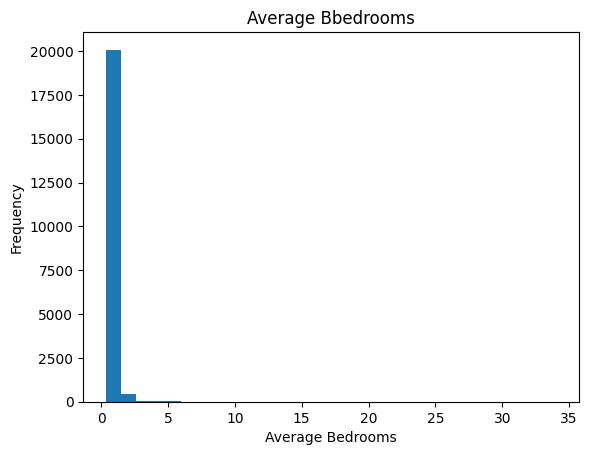

In [11]:
print("the skewness of Average Bedrooms: {}".format(df['AveBedrms'].skew()))

plt.hist(df['AveBedrms'], bins=30)
plt.xlabel("Average Bedrooms")
plt.ylabel("Frequency")
plt.title("Average Bbedrooms")
plt.show()        
         

the skewness of population is :4.935858226727124


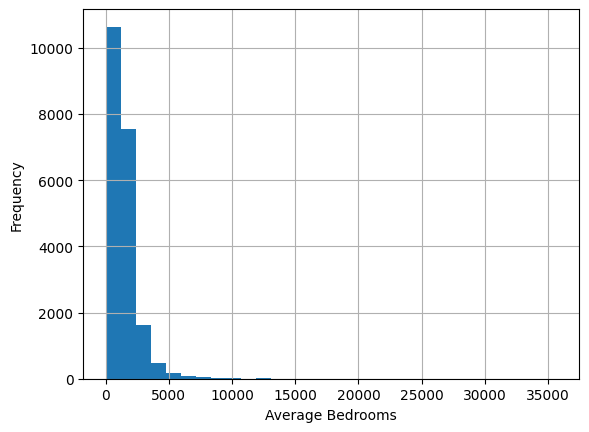

In [12]:
print("the skewness of population is :{}".format(df["Population"].skew()))
plt.hist(df['Population'], bins=30)
plt.xlabel("Average Bedrooms")
plt.ylabel("Frequency")
plt.grid()
plt.show()   

theskewness of AveOccup is : 97.63956096369486


<function matplotlib.pyplot.show(close=None, block=None)>

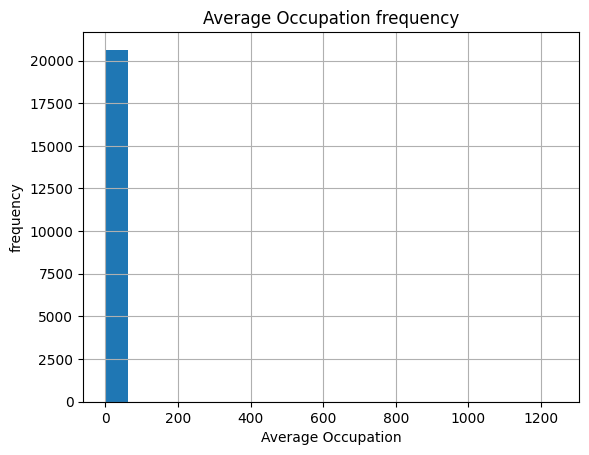

In [13]:
print("theskewness of AveOccup is : {}".format(df["AveOccup"].skew()))
plt.hist(df['AveOccup'], bins =20)
plt.xlabel("Average Occupation")
plt.ylabel("frequency")
plt.title("Average Occupation frequency")
plt.grid()
plt.show

theskewness of Latitude is : 0.4659530037099799


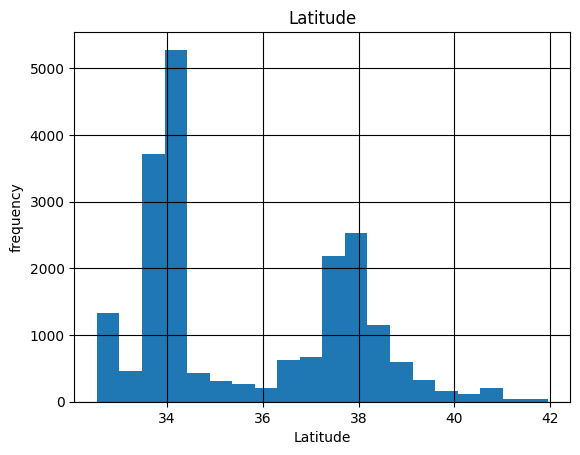

In [14]:
print("theskewness of Latitude is : {}".format(df["Latitude"].skew()))
plt.hist(df['Latitude'], bins =20)
plt.xlabel("Latitude")
plt.ylabel("frequency")
plt.title("Latitude")
plt.grid(color = "black")
plt.show()

theskewness of Longitude is : -0.2978012079524363


<function matplotlib.pyplot.show(close=None, block=None)>

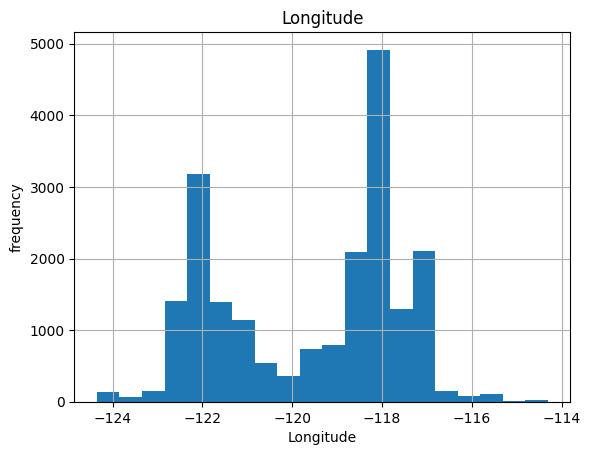

In [15]:

print("theskewness of Longitude is : {}".format(df["Longitude"].skew()))
plt.hist(df['Longitude'], bins =20)
plt.xlabel("Longitude")
plt.ylabel("frequency")
plt.title("Longitude")
plt.grid()
plt.show

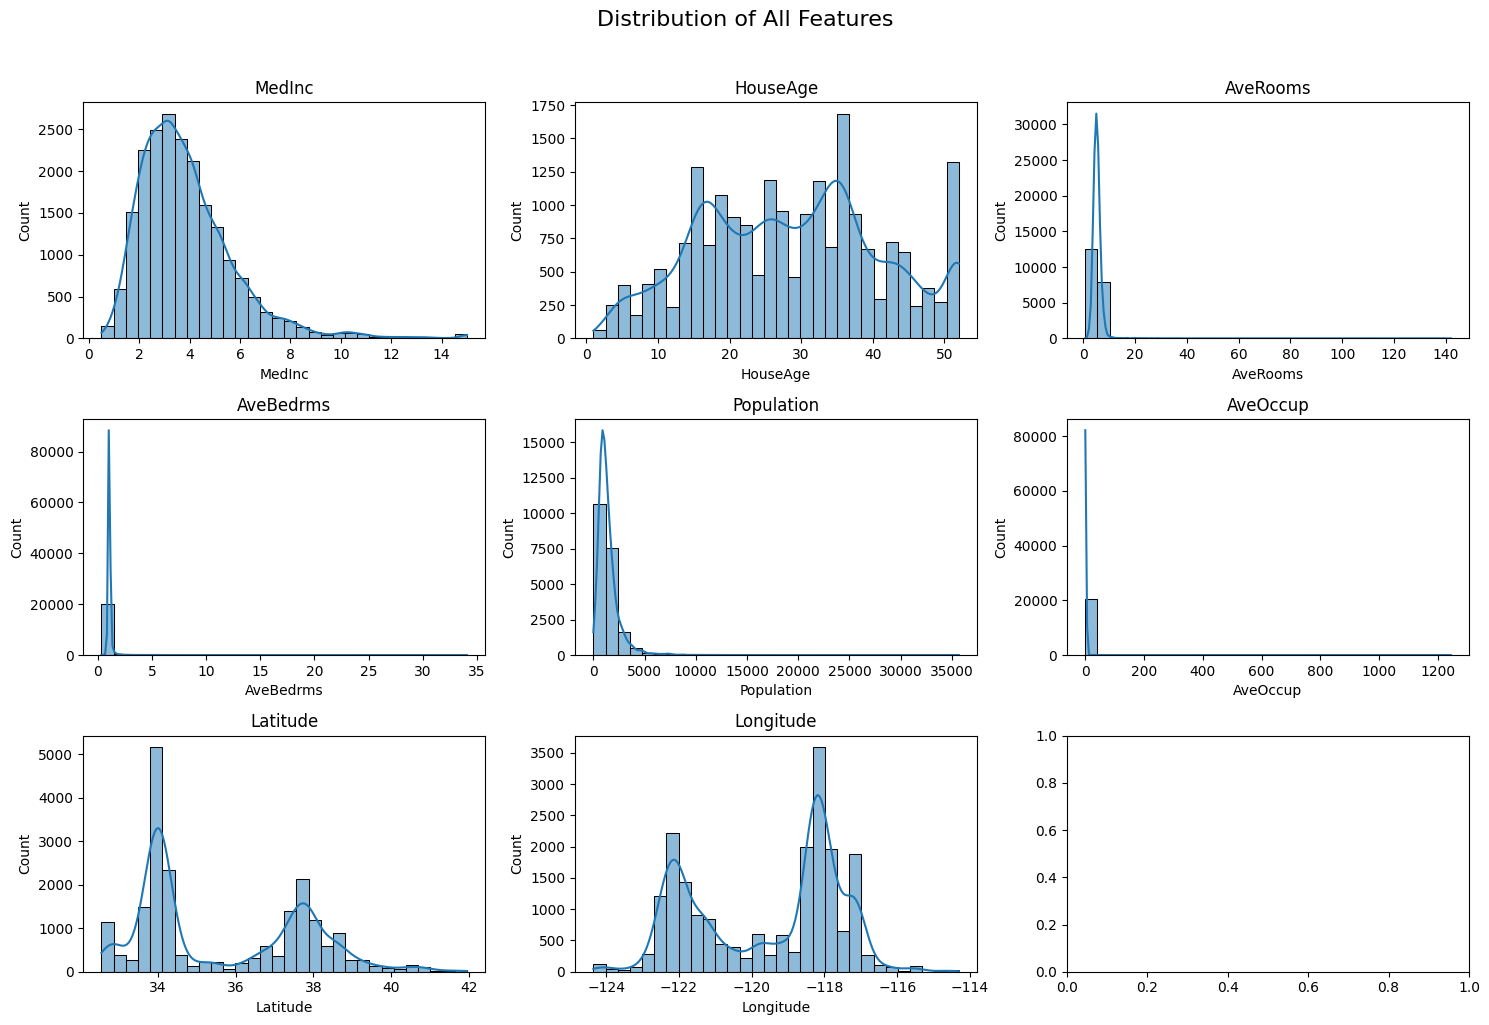

In [16]:
import seaborn as sns

fig, axes = plt.subplots(3, 3, figsize=(15, 10))
axes = axes.flatten()

for i, col in enumerate(df.columns):
    sns.histplot(df[col], ax=axes[i], bins=30, kde=True)
    axes[i].set_title(col)

plt.suptitle('Distribution of All Features', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

In [17]:
# Removing Outliers

from scipy import stats
df = df[(np.absolute(stats.zscore(df)) < 3).all(axis = 1)]

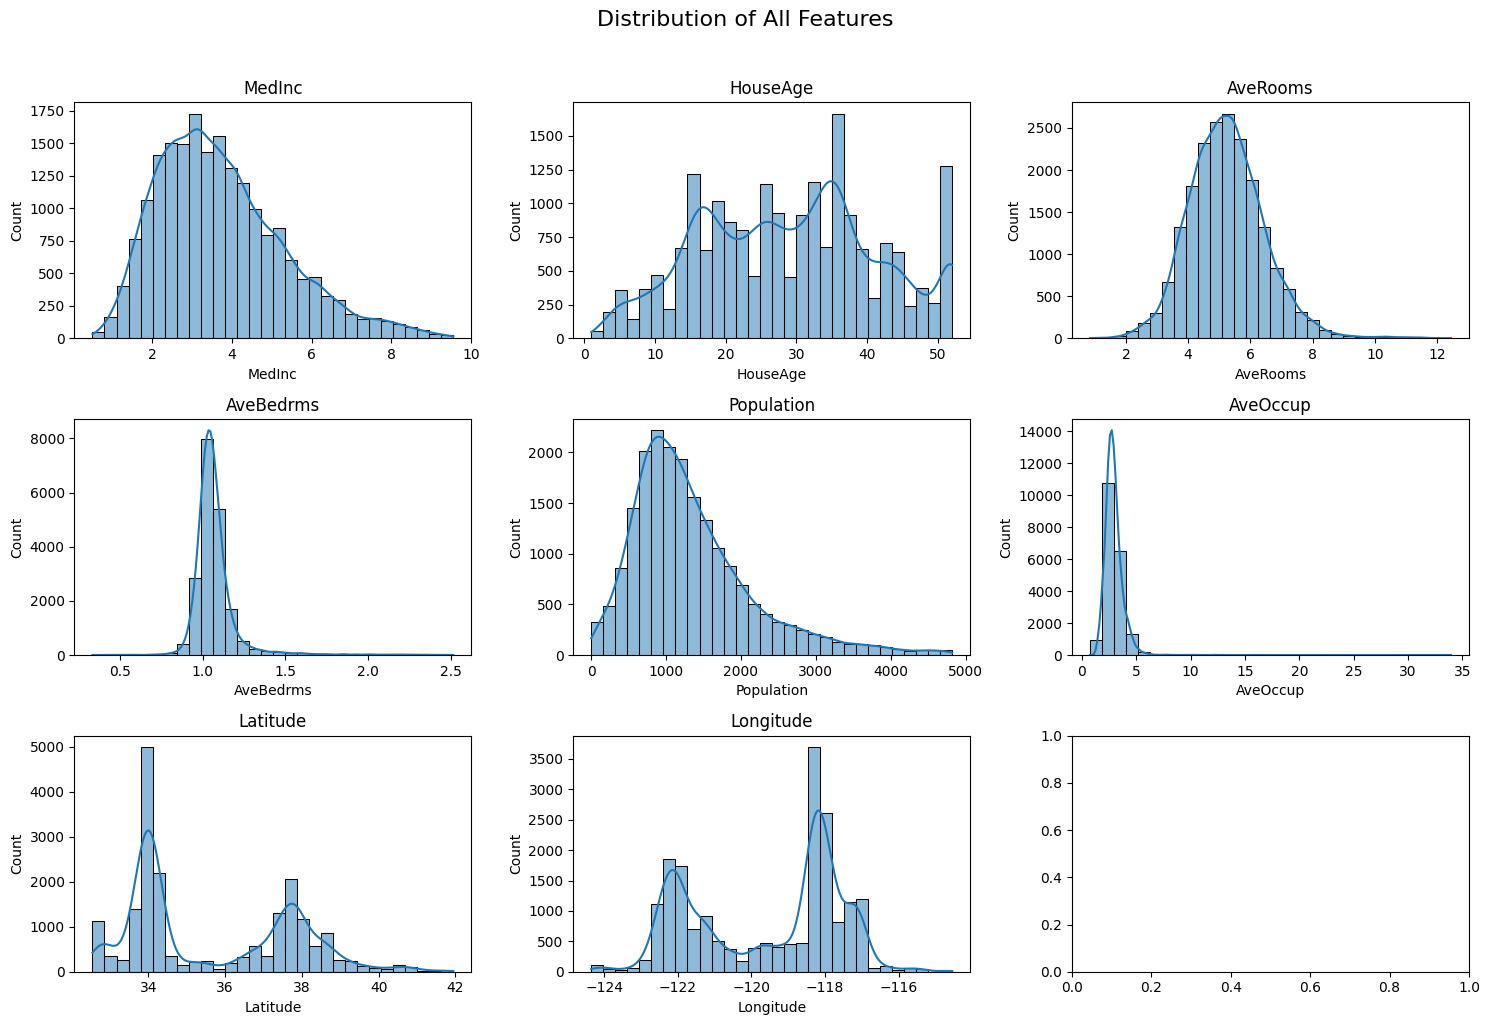

In [18]:
import seaborn as sns

fig, axes = plt.subplots(3, 3, figsize=(15, 10))
axes = axes.flatten()

for i, col in enumerate(df.columns):
    sns.histplot(df[col], ax=axes[i], bins=30, kde=True)
    axes[i].set_title(col)

plt.suptitle('Distribution of All Features', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

In [19]:
print(df.corr)
print("the largest columns correlated to MedInc: {}".format(df.corr()["MedInc"].nlargest(4)))

<bound method DataFrame.corr of        MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0      8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1      8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2      7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3      5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4      3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   
...       ...       ...       ...        ...         ...       ...       ...   
20635  1.5603      25.0  5.045455   1.133333       845.0  2.560606     39.48   
20636  2.5568      18.0  6.114035   1.315789       356.0  3.122807     39.49   
20637  1.7000      17.0  5.205543   1.120092      1007.0  2.325635     39.43   
20638  1.8672      18.0  5.329513   1.171920       741.0  2.123209     39.43   
20639  2.3886      16.0  5.254717   1.162264      1387.0  2.616981     39.37   

       

In [20]:
# Feature engineeering and data preprocessing 

#Feature Engineering: Adding additional columns to features to boost the signal on target variable
df['rooms_per_person'] = df["AveRooms"] /df["AveOccup"]
df["bedroom_ratio"] = df["AveBedrms"] / df["AveRooms"]
df["people_per_household"] = df["Population"] / df["AveOccup"]

#features splitting
x = df.drop(["MedInc"], axis = 1)
y = df["MedInc"]

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size = 0.3, random_state = 42)
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(13855, 10)
(5939, 10)
(13855,)
(5939,)


In [21]:
#  Features preprocessing
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns = x.columns)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns = X_test.columns)
print(X_train_scaled.shape)
print(X_test_scaled.shape)
print(X_train_scaled.describe().round(2))


(13855, 10)
(5939, 10)
       HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
count  13855.00  13855.00   13855.00    13855.00  13855.00  13855.00   
mean       0.00     -0.00       0.00       -0.00      0.00      0.00   
std        1.00      1.00       1.00        1.00      1.00      1.00   
min       -2.25     -3.60      -5.23       -1.65     -2.58     -1.45   
25%       -0.80     -0.69      -0.47       -0.68     -0.59     -0.81   
50%        0.00     -0.05      -0.15       -0.22     -0.13     -0.65   
75%        0.65      0.60       0.23        0.43      0.42      0.97   
max        1.85      5.91      10.68        4.28     21.78      2.95   

       Longitude  rooms_per_person  bedroom_ratio  people_per_household  
count   13855.00          13855.00       13855.00              13855.00  
mean       -0.00              0.00           0.00                  0.00  
std         1.00              1.00           1.00                  1.00  
min        -2.37             -3.

In [22]:
# Training the model
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
models = {
    "LinearRegression": LinearRegression(),
    "Random Forest": RandomForestRegressor(random_state = 42),
    "Gradient Boosting": GradientBoostingRegressor(random_state = 42)
}
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    print(f"\n{name}")
    print(f" R^2 : {r2_score(y_test, y_pred):.4f}")
    print(f" RMSE : {np.sqrt(mean_squared_error(y_test, y_pred)):.4}")
    print(f" MAE : {mean_absolute_error(y_test,y_pred):.4}")


LinearRegression
 R^2 : 0.6866
 RMSE : 0.8964
 MAE : 0.6819

Random Forest
 R^2 : 0.8007
 RMSE : 0.7149
 MAE : 0.5262

Gradient Boosting
 R^2 : 0.7856
 RMSE : 0.7415
 MAE : 0.5529


In [26]:
from sklearn.model_selection import RandomizedSearchCV

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

random_search = RandomizedSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid,
    n_iter=20,       # only 20 combinations instead of 144
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=2,
    random_state=42
)

random_search.fit(X_train_scaled, y_train)
print("Best parameters:", random_search.best_params_)
print("Best R²:", random_search.best_score_.round(4))

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best parameters: {'n_estimators': 300, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_depth': 30}
Best R²: 0.8004


In [27]:
best_model = random_search.best_estimator_

train_r2 = best_model.score(X_train_scaled, y_train)
test_r2 = best_model.score(X_test_scaled, y_test)

print(f"Train R²: {train_r2:.4f}")
print(f"Test R²:  {test_r2:.4f}")
print(f"Difference: {train_r2 - test_r2:.4f}")

Train R²: 0.9562
Test R²:  0.8021
Difference: 0.1541


In [29]:
# Force simpler trees to reduce overfitting
better_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=10,        # reduce from 30 → 10
    min_samples_split=10, # increase from 5 → 10
    min_samples_leaf=4,   # increase from 2 → 4
    random_state=42
)

better_model.fit(X_train_scaled, y_train)

train_r2 = better_model.score(X_train_scaled, y_train)
test_r2 = better_model.score(X_test_scaled, y_test)

print(f"Train R²: {train_r2:.4f}")
print(f"Test R²:  {test_r2:.4f}")
print(f"Difference: {train_r2 - test_r2:.4f}")

Train R²: 0.8582
Test R²:  0.7876
Difference: 0.0706


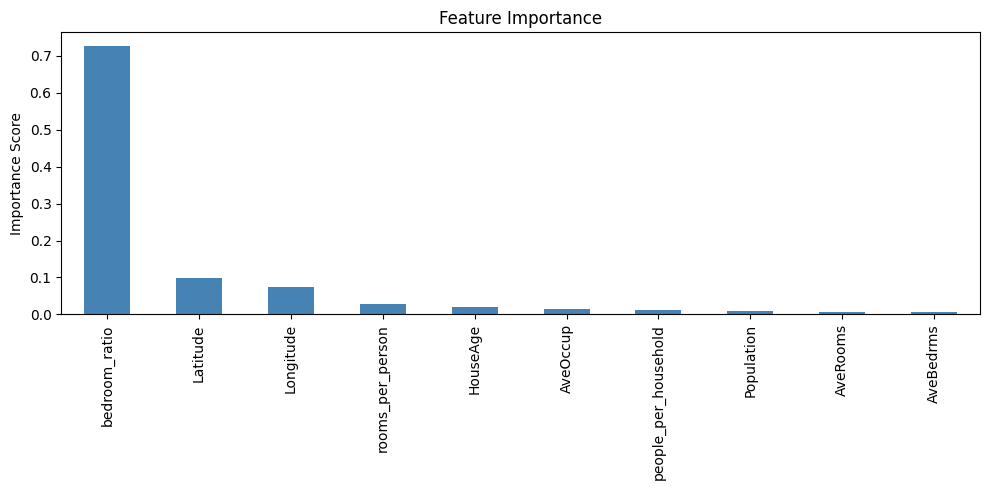

In [30]:
feat_importance = pd.Series(
    better_model.feature_importances_,
    index=x.columns
).sort_values(ascending=False)

feat_importance.plot(kind='bar', figsize=(10, 5), color='steelblue')
plt.title("Feature Importance")
plt.ylabel("Importance Score")
plt.tight_layout()
plt.show()

In [31]:
import joblib
joblib.dump(better_model, 'best_model.pkl')
joblib.dump(scaler, 'scaler.pkl')
print("Model saved successfully!")

Model saved successfully!
